In [12]:
import copy
import cv2
import glob
import math
import matplotlib.pyplot as plt
from matplotlib import colors
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import numpy as np
import os
import pandas as pd
import seaborn as sns
from astropy.io import fits
import torch
from torch.utils.data import Dataset
from torchmetrics import Dice
from torchmetrics import Dice, JaccardIndex
import segmentation_models_pytorch as smp

In [13]:
hiperparametros = {'nombre_notebook': 'Evaluation_NISP_H_1000imgs_v13_log_no_aug.ipynb',
                    'nombre_experimento' : 'Evaluation_NISP_H_1000imgs_v13_log_no_aug_pad',
                    'nombre_mejor_modelo_entrenado' : 'NISP_H_1000imgs_v13_log_no_aug_pad',
                    'device' : torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
                    'ruta_galaxias' : 'galaxies_test_NISP_H/galaxy_and_stream_convolved*.fits',
                    'ruta_mascaras' : '../masks_train_NISP_H/mask_',
                    'ancho_imagen_original' : 200,
                    'alto_imagen_original' : 200,
                    'ancho_imagen_deseado' : 224,
                    'alto_imagen_deseado' : 224}

In [14]:
def pad_to_size(image, target_h, target_w, pad_value=0):
    """Hace padding para alcanzar el tamaño deseado sin deformar"""
    h, w = image.shape[:2]
    pad_h = target_h - h
    pad_w = target_w - w
    
    # Padding simétrico
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    
    if len(image.shape) == 2:  # Para máscaras
        return np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), 
                     mode='constant', constant_values=pad_value)
    else:  # Para imágenes RGB
        return np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), 
                     mode='constant', constant_values=pad_value)


In [15]:
def get_galaxy_number(galaxy_name:str):
    return os.path.basename(galaxy_name).split('_')[4]

def get_galaxy_magnitude(galaxy_name:str):
    return os.path.basename(galaxy_name).split('_')[5]

def normalize_01(inp: np.ndarray):
    """Squash image input to the value range [0, 1] (no clipping)"""
    inp_out = (inp - np.min(inp)) / np.ptp(inp)
    return inp_out

def imagen_logaritmica(img: np.ndarray)->np.ndarray:
    """
    Escalamos de forma logarítmica la imagen para aumentar el contraste
    """
    img_log = np.log(img, where=(img>0))
    valor_minimo = np.min(img_log)
    np.putmask(img_log, img!=0, img_log+abs(valor_minimo))
    return img_log

In [16]:
def get_mag_stream_percentage(galaxy_number):
    
    path_catalogs_folder = "../../dataset_generation/catalogs_for_checking" 
    path_catalog = os.path.join(path_catalogs_folder, "stream_characteristics_"+str(galaxy_number)+".txt")
    df = pd.read_csv(path_catalog, delimiter=r"\s+", engine="python")
    mag_bulge = df.iloc[1, 3]
    mag_disk = df.iloc[1, 8]
    mag_stream = df.iloc[1, 13]
    zeropoint= 30.132  # For VIS, (For NISP is 30)
    flux_bulge = 10**((mag_bulge-zeropoint)/(-2.5)) 
    flux_disk = 10**((mag_disk-zeropoint)/(-2.5))
    flux_galaxy = flux_bulge + flux_disk
    flux_stream = 10**((mag_stream-zeropoint)/(-2.5)) 
    mag_stream_percentage = flux_stream/flux_galaxy
    mag_stream_percentage_rounded_up = math.ceil(mag_stream_percentage*100)
    if mag_stream_percentage_rounded_up == 6:
        mag_stream_percentage_rounded_up = 5
    #print("MAG_STREAM_PERCENTAGE: " + str(mag_stream_percentage) + "->" + str(mag_stream_percentage_rounded_up)+ "%")
    return mag_stream_percentage_rounded_up

In [17]:
def get_distance_to_galaxy_center(galaxy_number):
    path_catalogs_folder = "../../dataset_generation/catalogs_for_checking" 
    path_catalog = os.path.join(path_catalogs_folder, "stream_characteristics_"+str(galaxy_number)+".txt")
    df = pd.read_csv(path_catalog, delimiter=r"\s+", engine="python")
    distance_to_galaxy_center = df.iloc[1,14]
    #print("RR_STREAM: " + str(distance_to_galaxy_center))
    return distance_to_galaxy_center

In [18]:
class MyDataset(Dataset):
    """
    Dataset básico sin ningún tipo de augmentation
    """
    def __init__(self, galaxias_con_colas_de_marea, transform=None):
        """
        Constructor del dataset
        @param galaxias_con_colas_de_marea: Lista de rutas a los ficheros que contienen los datos de las galaxias
        """
        self.galaxias_con_colas_de_marea = galaxias_con_colas_de_marea
        self.transform=transform

    def __getitem__(self, index):
        #Abrimos la imagen de la galaxia con cola de marea
        ruta = self.galaxias_con_colas_de_marea[index]
        magnitud_real = get_galaxy_magnitude(ruta)
        
        galaxy_fits = fits.open(self.galaxias_con_colas_de_marea[index])
        x = galaxy_fits[0].data.astype(np.float32)
        #Abrimos la mascara correspondiente a la imagen
        numero_galaxia = get_galaxy_number(self.galaxias_con_colas_de_marea[index])
        magnitud_galaxia = get_galaxy_magnitude(self.galaxias_con_colas_de_marea[index])
        mag_stream_percentage = get_mag_stream_percentage(numero_galaxia)
        distance_to_galaxy_center = get_distance_to_galaxy_center(numero_galaxia)
        y = np.array(cv2.imread(hiperparametros['ruta_mascaras']+str(numero_galaxia)+"_"+str(magnitud_galaxia)+".png",0)).astype(np.float32)
        #x = normalize_01(x)
        x_tensor_visualizar = copy.deepcopy(x)
        x = imagen_logaritmica(x)

        x = normalize_01(x)

        x = pad_to_size(x, hiperparametros['alto_imagen_deseado'], hiperparametros['ancho_imagen_deseado'])
        y = pad_to_size(y, hiperparametros['alto_imagen_deseado'], hiperparametros['ancho_imagen_deseado'])
        if(self.transform is not None):
            augmented = self.transform(image=x, mask=y)
            x_tensor= augmented["image"]
            y_tensor= augmented["mask"].long()
        else:
            x_tensor = torch.from_numpy(x).float()
            x_tensor=torch.unsqueeze(x_tensor, dim=0)
            y_tensor = torch.from_numpy(y).long()
        
        #Hacemos reshape de los tensores
        y_tensor=torch.unsqueeze(y_tensor, dim=0)
        return x_tensor, y_tensor, ruta, magnitud_real, x_tensor_visualizar, mag_stream_percentage, distance_to_galaxy_center
    
    def __len__(self):
        """
        Devuelve la longitud del dataset
        """
        return len(self.galaxias_con_colas_de_marea)

In [19]:
dice = Dice(num_classes=2, average='macro', ignore_index=0)
iou = JaccardIndex(task='multiclass', num_classes=2, average='none', ignore_index=0)
imagenes_test = glob.glob(hiperparametros['ruta_galaxias'])
imagenes_test.sort()
#Cargamos el dataset de test
test_dataset= MyDataset(imagenes_test)
print("Number of valid images: " + str(len(imagenes_test)))
device = hiperparametros['device']
#dice.to(device)

Number of valid images: 1750


In [20]:
unet = smp.Unet(
    encoder_name="resnet18",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=2,                      # model output channels (number of classes in your dataset)
)

In [21]:
#Cargamos el modelo previamente entrenado
ruta_modelo = hiperparametros['nombre_mejor_modelo_entrenado']
mejor_modelo = unet
mejor_modelo.load_state_dict(torch.load(ruta_modelo))
mejor_modelo.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

Calculando rango de distancias del dataset...
Distancia mínima: 2.00
Distancia máxima: 39.67

Bins de distancia creados: [2, 10, 17, 25, 32, 40]
Etiquetas: ['2-10', '10-17', '17-25', '25-32', '32-40']
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.05_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.05, Dice: 0.5088 Iou :0.736, Distance: 24.0
min_sb: 24.9
max_sb: 25.748055


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


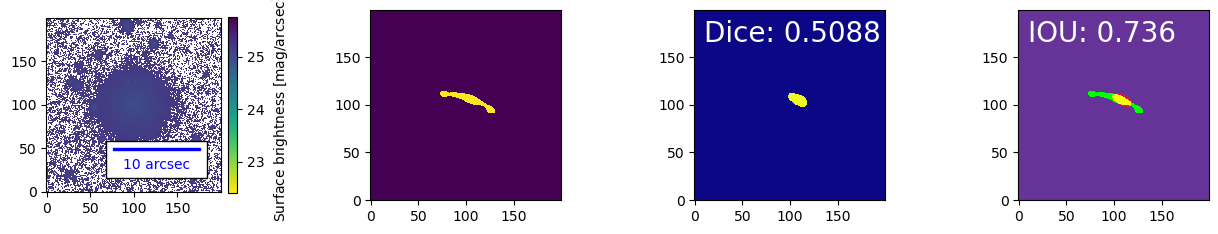

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.15_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.15, Dice: 0.5632 Iou :0.5815, Distance: 24.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.740295


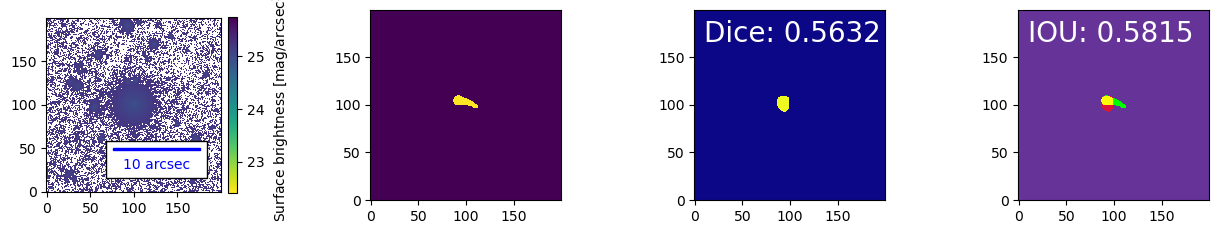

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.1_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.1, Dice: 0.5024 Iou :0.5676, Distance: 24.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.799383


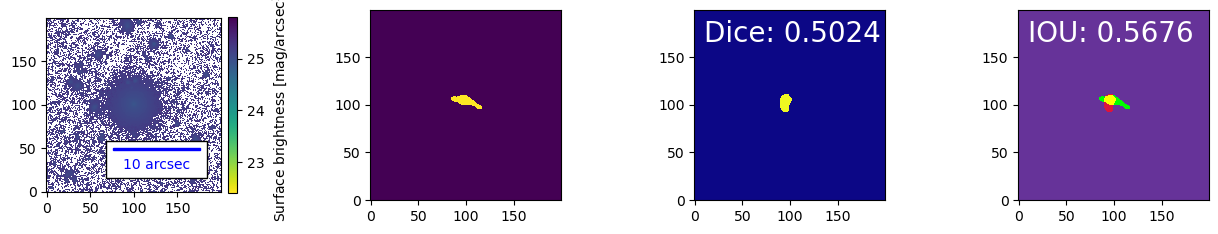

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.25_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.25, Dice: 0.5344 Iou :0.5645, Distance: 24.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.85407


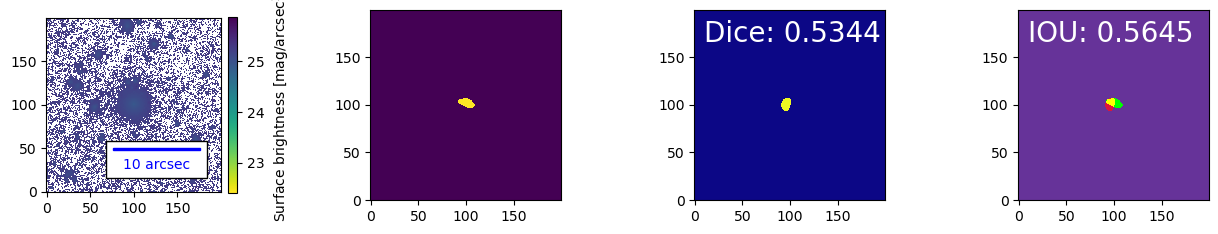

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.2_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.2, Dice: 0.6193 Iou :0.5477, Distance: 24.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.834705


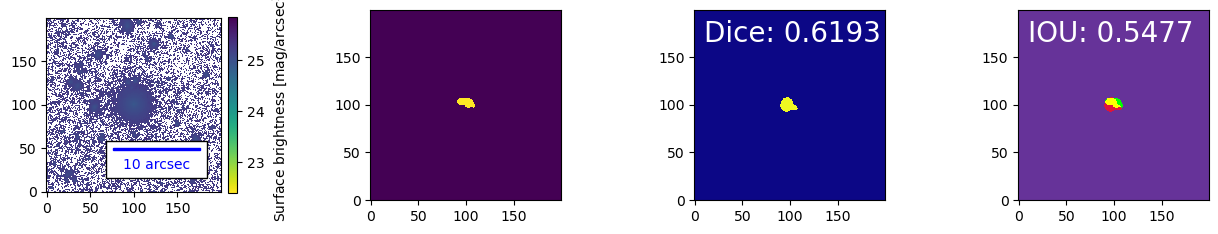

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.4_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.4, Dice: 0.7099 Iou :0.5962, Distance: 24.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.657978


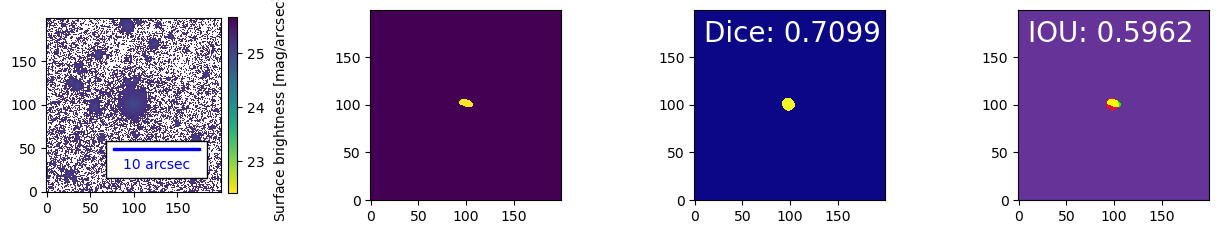

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.6_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.6, Dice: 0.6082 Iou :0.4906, Distance: 24.0
min_sb: 24.9
max_sb: 25.78977


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


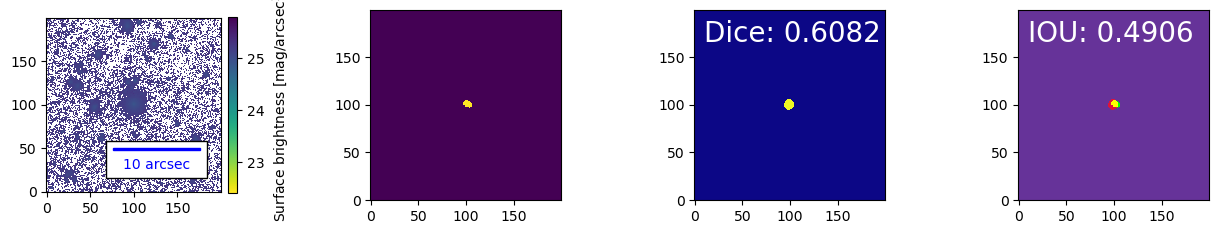

/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.8_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.8, Dice: 0.5695 Iou :0.4135, Distance: 24.0
min_sb: 24.9
max_sb: 25.810165


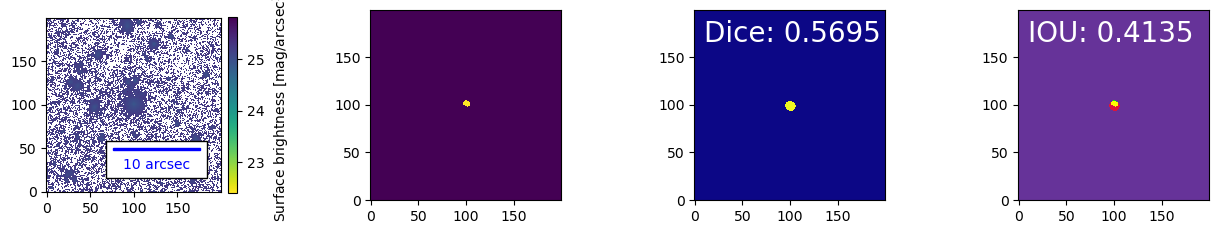

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_1_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 1, Dice: 0.6719 Iou :0.5181, Distance: 24.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.969952


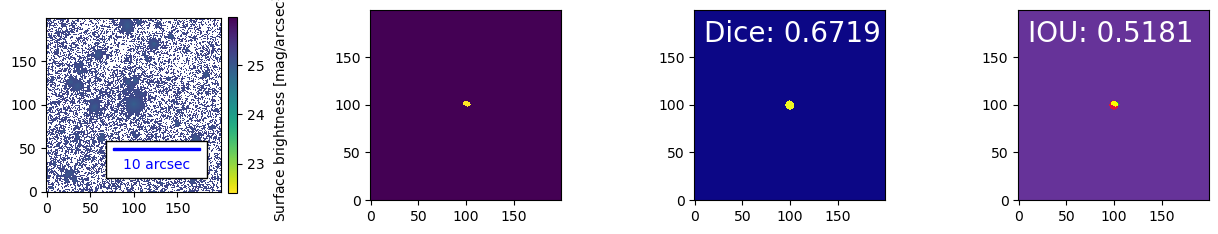

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_100_0.05_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.05, Dice: 0.8637 Iou :0.8199, Distance: 12.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.672607


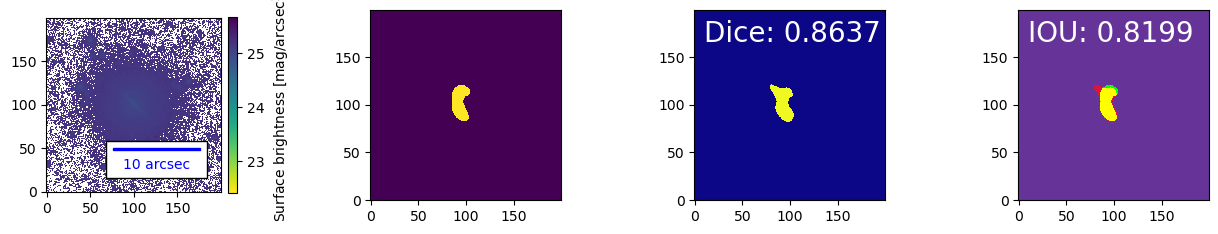

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_100_0.15_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.15, Dice: 0.869 Iou :0.8213, Distance: 12.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.786978


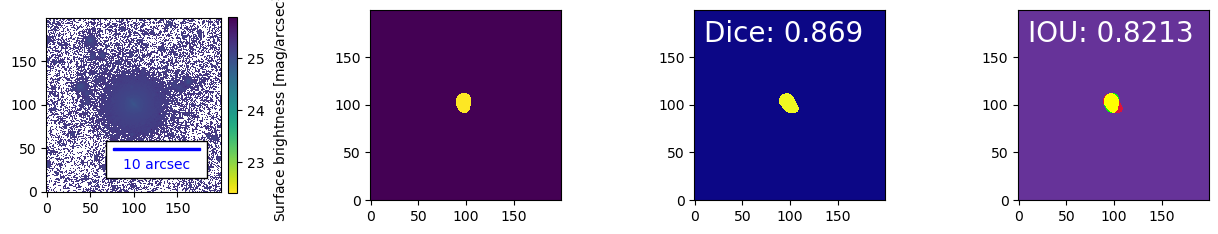

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_100_0.1_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.1, Dice: 0.817 Iou :0.7458, Distance: 12.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.684155


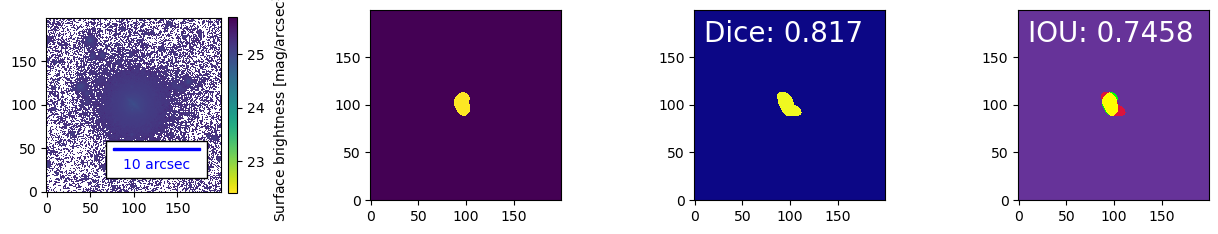

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_100_0.25_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.25, Dice: 0.7627 Iou :0.8994, Distance: 12.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.865486


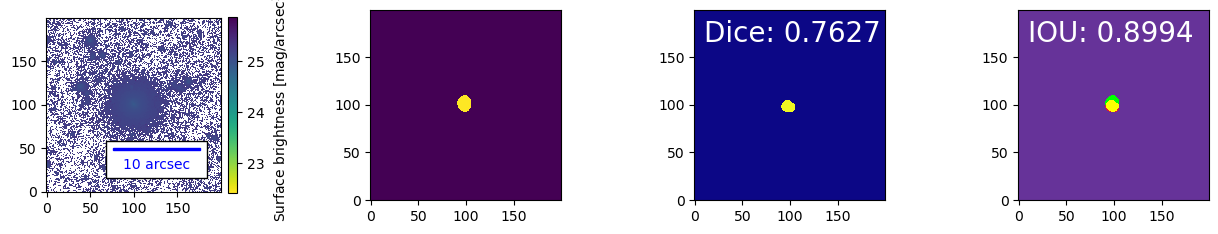

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_100_0.2_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.2, Dice: 0.8444 Iou :0.9135, Distance: 12.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.872807


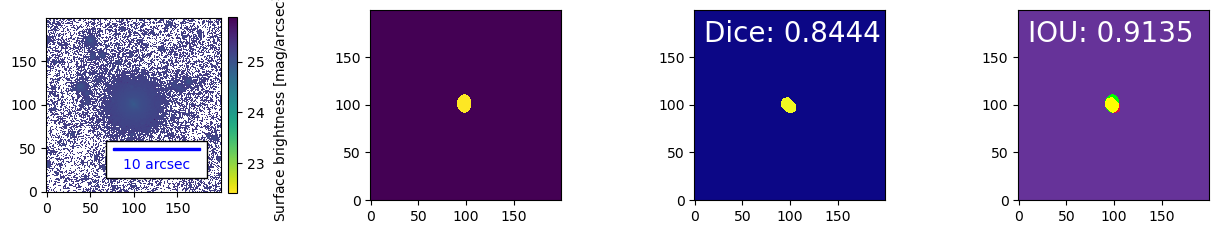

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_100_0.4_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.4, Dice: 0.8364 Iou :0.8571, Distance: 12.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.939383


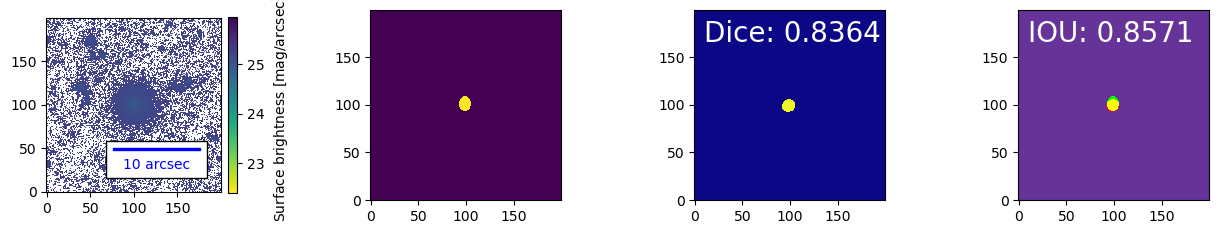

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_100_0.6_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.6, Dice: 0.8091 Iou :0.957, Distance: 12.0


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


min_sb: 24.9
max_sb: 25.932236


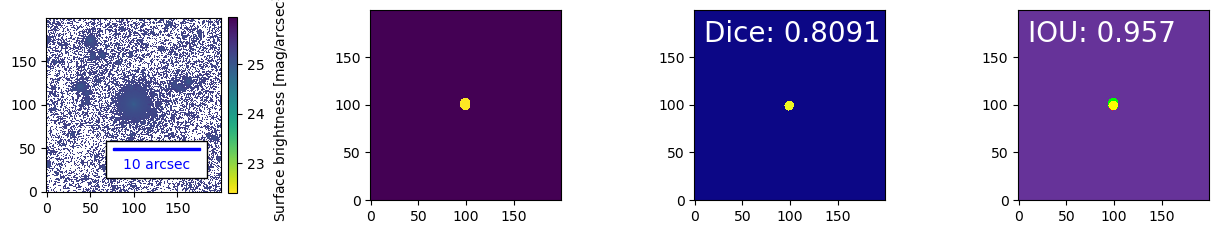

Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_100_0.8_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.8, Dice: 0.7826 Iou :0.81, Distance: 12.0
min_sb: 24.9
max_sb: 25.690315


/tmp/ipykernel_1960717/526293530.py:179: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


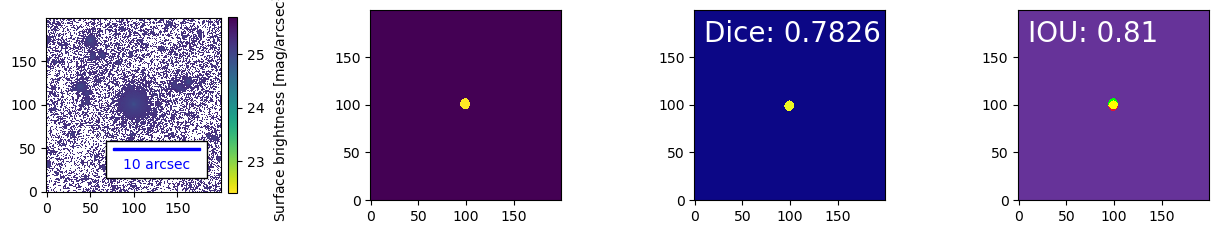

In [ ]:
# ==========================================
# 1. DEFINICIÓN DE ESTRUCTURAS DE DATOS
# ==========================================
resultados_dice = {
    '0.05':[], '0.1':[], '0.15':[], '0.2':[], '0.25':[],
    '0.4':[], '0.6':[], '0.8':[], '1':[],
}
resultados_iou = {
    '0.05':[], '0.1':[], '0.15':[], '0.2':[], '0.25':[],
    '0.4':[], '0.6':[], '0.8':[], '1':[],
}

dice_results_redshift_with_mag_stream_percentage = {
    '0.05':{1:[],2:[],3:[],4:[],5:[],},
    '0.1':{1:[],2:[],3:[],4:[],5:[],},
    '0.15':{1:[],2:[],3:[],4:[],5:[],},
    '0.2':{1:[],2:[],3:[],4:[],5:[],},
    '0.25':{1:[],2:[],3:[],4:[],5:[],},
    '0.4':{1:[],2:[],3:[],4:[],5:[],},
    '0.6':{1:[],2:[],3:[],4:[],5:[],},
    '0.8':{1:[],2:[],3:[],4:[],5:[],},
    '1':{1:[],2:[],3:[],4:[],5:[],},
}

iou_results_redshift_with_mag_stream_percentage = {
    '0.05':{1:[],2:[],3:[],4:[],5:[],},
    '0.1':{1:[],2:[],3:[],4:[],5:[],},
    '0.15':{1:[],2:[],3:[],4:[],5:[],},
    '0.2':{1:[],2:[],3:[],4:[],5:[],},
    '0.25':{1:[],2:[],3:[],4:[],5:[],},
    '0.4':{1:[],2:[],3:[],4:[],5:[],},
    '0.6':{1:[],2:[],3:[],4:[],5:[],},
    '0.8':{1:[],2:[],3:[],4:[],5:[],},
    '1':{1:[],2:[],3:[],4:[],5:[],},
}

# NUEVAS ESTRUCTURAS PARA DISTANCIA
dice_results_redshift_with_distance = {
    '0.05':{}, '0.1':{}, '0.15':{}, '0.2':{}, '0.25':{},
    '0.4':{}, '0.6':{}, '0.8':{}, '1':{},
}

iou_results_redshift_with_distance = {
    '0.05':{}, '0.1':{}, '0.15':{}, '0.2':{}, '0.25':{},
    '0.4':{}, '0.6':{}, '0.8':{}, '1':{},
}

# ==========================================
# CALCULAR BINS AUTOMÁTICAMENTE
# ==========================================
print("Calculando rango de distancias del dataset...")

# Recopilar todas las distancias del dataset
all_distances = []
for i in range(len(test_dataset)):
    item = test_dataset.__getitem__(i)
    all_distances.append(item[6])

# Calcular mínimo y máximo
min_distance = min(all_distances)
max_distance = max(all_distances)

print(f"Distancia mínima: {min_distance:.2f}")
print(f"Distancia máxima: {max_distance:.2f}")

# Redondear para tener límites enteros
import math
min_distance_rounded = math.floor(min_distance)  # Redondear hacia abajo
max_distance_rounded = math.ceil(max_distance)   # Redondear hacia arriba

# Crear 5 intervalos iguales
num_bins = 5
bin_width = (max_distance_rounded - min_distance_rounded) / num_bins

# Generar los bins
distance_bins = [min_distance_rounded + i * bin_width for i in range(num_bins + 1)]
# Redondear cada bin a entero
distance_bins = [round(b) for b in distance_bins]

# Crear las etiquetas
distance_labels = [f"{distance_bins[i]}-{distance_bins[i+1]}" for i in range(num_bins)]

print(f"\nBins de distancia creados: {distance_bins}")
print(f"Etiquetas: {distance_labels}")

# ==========================================
# 2. EVALUACIÓN EN TEST DATASET
# ==========================================
ancho = hiperparametros['ancho_imagen_deseado']
alto = hiperparametros['alto_imagen_deseado']
mejor_modelo.eval()
pasos_test = 0
dice_medio_test = 0
iou_medio_test = 0
zp = 29.9
pix_scale = 0.3

for i in range(int(len(test_dataset)*0.01)):
    item_dataset = test_dataset.__getitem__(i)
    item_x = item_dataset[0].reshape((1,1,ancho,alto)).cpu().detach().squeeze().numpy()
    item_label = item_dataset[1].reshape((1,1,ancho,alto)).cpu().detach().squeeze().numpy()
    x_tensor_visualizar = item_dataset[0].reshape((1,1,ancho,alto)).cpu().detach().squeeze().numpy()
    
    # Si la máscara es vacía no intentamos segmentarla
    if(np.count_nonzero(item_label)!=0):
        # Obtenemos predicción de la red
        prediccion_item_tensor = mejor_modelo(item_dataset[0].reshape((1,1,ancho,alto)).to(device)).cpu().detach().squeeze()   
        mascara_predicha = torch.argmax(prediccion_item_tensor, dim=0).numpy()
        valor_dice = dice(torch.from_numpy(item_label), torch.from_numpy(mascara_predicha))
        valor_iou = iou(torch.from_numpy(item_label), torch.from_numpy(mascara_predicha))[1]
        
        magnitud = item_dataset[3]
        mag_stream_percentage = item_dataset[5]
        distance_to_galaxy_center = item_dataset[6]
        
        print("Path: "+item_dataset[2]+ "\nMagnitud: "+ magnitud + 
              ", Dice: "+str(round(valor_dice.item(), 4))+" Iou :" + str(round(valor_iou.item(), 4))+
              ", Distance: "+str(round(distance_to_galaxy_center, 2)))
        
        # Almacenar en estructuras existentes
        resultados_dice[magnitud].append(valor_dice.item())
        resultados_iou[magnitud].append(valor_iou.item())
        dice_results_redshift_with_mag_stream_percentage[magnitud][mag_stream_percentage].append(valor_dice.item())
        iou_results_redshift_with_mag_stream_percentage[magnitud][mag_stream_percentage].append(valor_iou.item())
        
        # NUEVO: Determinar bin de distancia y almacenar
        distance_bin_idx = None
        for idx in range(len(distance_bins) - 1):
            if distance_bins[idx] <= distance_to_galaxy_center < distance_bins[idx + 1]:
                distance_bin_idx = idx
                break
        
        # Caso especial: si es exactamente el valor máximo
        if distance_to_galaxy_center == distance_bins[-1]:
            distance_bin_idx = len(distance_bins) - 2
        
        if distance_bin_idx is not None:
            distance_label = distance_labels[distance_bin_idx]
            
            # Inicializar si no existe
            if distance_label not in dice_results_redshift_with_distance[magnitud]:
                dice_results_redshift_with_distance[magnitud][distance_label] = []
                iou_results_redshift_with_distance[magnitud][distance_label] = []
            
            # Añadir resultados
            dice_results_redshift_with_distance[magnitud][distance_label].append(valor_dice.item())
            iou_results_redshift_with_distance[magnitud][distance_label].append(valor_iou.item())
        
        dice_medio_test += valor_dice.item()
        iou_medio_test += valor_iou.item()
        pasos_test += 1
        
        #Mostramos imagen, mascara y mascara predicha
        item_x = item_x.astype(np.float32)   
        item_label = item_label.astype(np.uint8)
        mascara_predicha = mascara_predicha.astype(np.float32)  

        # Quitar el padding al mostrar
        crop = 12
        item_x = item_x[crop:-crop, crop:-crop]
        item_label = item_label[crop:-crop, crop:-crop]
        mascara_predicha = mascara_predicha[crop:-crop, crop:-crop]

        x_tensor_visualizar = x_tensor_visualizar[crop:-crop, crop:-crop]
        zeros = np.zeros((hiperparametros['ancho_imagen_original'], hiperparametros['ancho_imagen_original']))
        ones = np.ones((hiperparametros['ancho_imagen_original'], hiperparametros['ancho_imagen_original']))

        cmap = colors.ListedColormap(['rebeccapurple', 'yellow', 'crimson', 'lime'])
        bounds=[0,1,2,3,4]
        norm = colors.BoundaryNorm(bounds, cmap.N)
        dif = np.zeros((hiperparametros['ancho_imagen_original'], hiperparametros['ancho_imagen_original']))
        dif[ ( item_label == zeros ) & (mascara_predicha == zeros) ] = 0
        dif[ (item_label == ones ) & (mascara_predicha == ones) ] = 1
        dif[ (item_label == zeros) & (mascara_predicha == ones) ] = 2
        dif[ (item_label == ones) & (mascara_predicha == zeros)] = 3

        fig, (axs0, axs1, axs2, axs3) = plt.subplots(1, 4, figsize=(15, 15))

        sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))

        # Filtrar inf y nan para calcular los límites
        sb_valid = sb_array[np.isfinite(sb_array)]
        min_sb = np.min(sb_valid)
        max_sb = np.max(sb_valid)

        print("min_sb: "+ str(min_sb))
        print("max_sb: "+ str(max_sb))
        # Usar axs0 en lugar de plt
        imshow_img = axs0.imshow(sb_array, origin='lower', interpolation="none", cmap="viridis_r", vmin=max_sb, vmax=min_sb)
        cb = fig.colorbar(imshow_img, ax=axs0, fraction=0.046, pad=0.04)
        cb.set_label(r'Surface brightness [mag/arcsec$^{2}$]')

        # Usar axs0.transData en lugar de plt.gca().transData
        scalebar = AnchoredSizeBar(axs0.transData, 10./pix_scale, "10 arcsec", borderpad=1.0, sep=5, loc="lower right", pad=0.5, color="blue", frameon=True, size_vertical=3)
        axs0.add_artist(scalebar)

        axs1.imshow(item_label, interpolation='none', origin="lower")
        axs2.imshow(mascara_predicha, interpolation='none', origin="lower", cmap="plasma")
        axs2.text(0.05, 0.95, "Dice: "+str(round(valor_dice.item(), 4)), color='white', fontsize=20, ha='left', va='top', transform=axs2.transAxes)
        axs3.imshow(dif, interpolation='none', origin="lower", cmap=cmap, norm=norm)
        axs3.text(0.05, 0.95, "IOU: "+str(round(valor_iou.item(), 4)), color='white', fontsize=20, ha='left', va='top', transform=axs3.transAxes)
        plt.subplots_adjust(wspace=0.7)
        plt.show()

In [ ]:
# ==========================================
# 1. DEFINICIÓN DE ESTRUCTURAS DE DATOS
# ==========================================
resultados_dice = {
    '0.05':[], '0.1':[], '0.15':[], '0.2':[], '0.25':[],
    '0.4':[], '0.6':[], '0.8':[], '1':[],
}
resultados_iou = {
    '0.05':[], '0.1':[], '0.15':[], '0.2':[], '0.25':[],
    '0.4':[], '0.6':[], '0.8':[], '1':[],
}

dice_results_redshift_with_mag_stream_percentage = {
    '0.05':{1:[],2:[],3:[],4:[],5:[],},
    '0.1':{1:[],2:[],3:[],4:[],5:[],},
    '0.15':{1:[],2:[],3:[],4:[],5:[],},
    '0.2':{1:[],2:[],3:[],4:[],5:[],},
    '0.25':{1:[],2:[],3:[],4:[],5:[],},
    '0.4':{1:[],2:[],3:[],4:[],5:[],},
    '0.6':{1:[],2:[],3:[],4:[],5:[],},
    '0.8':{1:[],2:[],3:[],4:[],5:[],},
    '1':{1:[],2:[],3:[],4:[],5:[],},
}

iou_results_redshift_with_mag_stream_percentage = {
    '0.05':{1:[],2:[],3:[],4:[],5:[],},
    '0.1':{1:[],2:[],3:[],4:[],5:[],},
    '0.15':{1:[],2:[],3:[],4:[],5:[],},
    '0.2':{1:[],2:[],3:[],4:[],5:[],},
    '0.25':{1:[],2:[],3:[],4:[],5:[],},
    '0.4':{1:[],2:[],3:[],4:[],5:[],},
    '0.6':{1:[],2:[],3:[],4:[],5:[],},
    '0.8':{1:[],2:[],3:[],4:[],5:[],},
    '1':{1:[],2:[],3:[],4:[],5:[],},
}

# NUEVAS ESTRUCTURAS PARA DISTANCIA
dice_results_redshift_with_distance = {
    '0.05':{}, '0.1':{}, '0.15':{}, '0.2':{}, '0.25':{},
    '0.4':{}, '0.6':{}, '0.8':{}, '1':{},
}

iou_results_redshift_with_distance = {
    '0.05':{}, '0.1':{}, '0.15':{}, '0.2':{}, '0.25':{},
    '0.4':{}, '0.6':{}, '0.8':{}, '1':{},
}

# ==========================================
# CALCULAR BINS AUTOMÁTICAMENTE
# ==========================================
print("Calculando rango de distancias del dataset...")

# Recopilar todas las distancias del dataset
all_distances = []
for i in range(len(test_dataset)):
    item = test_dataset.__getitem__(i)
    all_distances.append(item[6])

# Calcular mínimo y máximo
min_distance = min(all_distances)
max_distance = max(all_distances)

print(f"Distancia mínima: {min_distance:.2f}")
print(f"Distancia máxima: {max_distance:.2f}")

# Redondear para tener límites enteros
import math
min_distance_rounded = math.floor(min_distance)  # Redondear hacia abajo
max_distance_rounded = math.ceil(max_distance)   # Redondear hacia arriba

# Crear 5 intervalos iguales
num_bins = 5
bin_width = (max_distance_rounded - min_distance_rounded) / num_bins

# Generar los bins
distance_bins = [min_distance_rounded + i * bin_width for i in range(num_bins + 1)]
# Redondear cada bin a entero
distance_bins = [round(b) for b in distance_bins]

# Crear las etiquetas
distance_labels = [f"{distance_bins[i]}-{distance_bins[i+1]}" for i in range(num_bins)]

print(f"\nBins de distancia creados: {distance_bins}")
print(f"Etiquetas: {distance_labels}")

# ==========================================
# 2. EVALUACIÓN EN TEST DATASET
# ==========================================
ancho = hiperparametros['ancho_imagen_deseado']
alto = hiperparametros['alto_imagen_deseado']
mejor_modelo.eval()
pasos_test = 0
dice_medio_test = 0
iou_medio_test = 0
zp = 29.9
pix_scale = 0.3

for i in range(int(len(test_dataset))):
    item_dataset = test_dataset.__getitem__(i)
    item_x = item_dataset[0].reshape((1,1,ancho,alto)).cpu().detach().squeeze().numpy()
    item_label = item_dataset[1].reshape((1,1,ancho,alto)).cpu().detach().squeeze().numpy()
    x_tensor_visualizar = item_dataset[0].reshape((1,1,ancho,alto)).cpu().detach().squeeze().numpy()
    
    # Si la máscara es vacía no intentamos segmentarla
    if(np.count_nonzero(item_label)!=0):
        # Obtenemos predicción de la red
        prediccion_item_tensor = mejor_modelo(item_dataset[0].reshape((1,1,ancho,alto)).to(device)).cpu().detach().squeeze()   
        mascara_predicha = torch.argmax(prediccion_item_tensor, dim=0).numpy()
        valor_dice = dice(torch.from_numpy(item_label), torch.from_numpy(mascara_predicha))
        valor_iou = iou(torch.from_numpy(item_label), torch.from_numpy(mascara_predicha))[1]
        
        magnitud = item_dataset[3]
        mag_stream_percentage = item_dataset[5]
        distance_to_galaxy_center = item_dataset[6]
        
        print("Path: "+item_dataset[2]+ "\nMagnitud: "+ magnitud + 
              ", Dice: "+str(round(valor_dice.item(), 4))+" Iou :" + str(round(valor_iou.item(), 4))+
              ", Distance: "+str(round(distance_to_galaxy_center, 2)))
        
        # Almacenar en estructuras existentes
        resultados_dice[magnitud].append(valor_dice.item())
        resultados_iou[magnitud].append(valor_iou.item())
        dice_results_redshift_with_mag_stream_percentage[magnitud][mag_stream_percentage].append(valor_dice.item())
        iou_results_redshift_with_mag_stream_percentage[magnitud][mag_stream_percentage].append(valor_iou.item())
        
        # NUEVO: Determinar bin de distancia y almacenar
        distance_bin_idx = None
        for idx in range(len(distance_bins) - 1):
            if distance_bins[idx] <= distance_to_galaxy_center < distance_bins[idx + 1]:
                distance_bin_idx = idx
                break
        
        # Caso especial: si es exactamente el valor máximo
        if distance_to_galaxy_center == distance_bins[-1]:
            distance_bin_idx = len(distance_bins) - 2
        
        if distance_bin_idx is not None:
            distance_label = distance_labels[distance_bin_idx]
            
            # Inicializar si no existe
            if distance_label not in dice_results_redshift_with_distance[magnitud]:
                dice_results_redshift_with_distance[magnitud][distance_label] = []
                iou_results_redshift_with_distance[magnitud][distance_label] = []
            
            # Añadir resultados
            dice_results_redshift_with_distance[magnitud][distance_label].append(valor_dice.item())
            iou_results_redshift_with_distance[magnitud][distance_label].append(valor_iou.item())
        
        dice_medio_test += valor_dice.item()
        iou_medio_test += valor_iou.item()
        pasos_test += 1

Calculando rango de distancias del dataset...
Distancia mínima: 2.00
Distancia máxima: 39.67

Bins de distancia creados: [2, 10, 17, 25, 32, 40]
Etiquetas: ['2-10', '10-17', '17-25', '25-32', '32-40']
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.05_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.05, Dice: 0.5088 Iou :0.736, Distance: 24.0
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.15_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.15, Dice: 0.5632 Iou :0.5815, Distance: 24.0
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.1_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.1, Dice: 0.5024 Iou :0.5676, Distance: 24.0
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.25_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.25, Dice: 0.5344 Iou :0.5645, Distance: 24.0
Path: galaxies_test_NISP_H/galaxy_and_stream_convolved_1000_0.2_NISP_H_in_EUC_NIR_H_LSB_ObsID_2706.fits
Magnitud: 0.2, Dice: 0.6193 Iou :0.5477, Distance:

In [24]:
dice_test_medio_total=dice_medio_test/pasos_test
print("Dice_medio_total="+str(dice_test_medio_total))

Dice_medio_total=0.5185697522164009


In [25]:
iou_test_medio_total=iou_medio_test/pasos_test
print("IOU_medio_total="+str(iou_test_medio_total))

IOU_medio_total=0.6425666845419054


In [26]:
# Filtrar NaNs y calcular la media para resultados_dice
dices_medios_por_magnitud = [np.mean([x for x in lista if not np.isnan(x)]) for lista in resultados_dice.values()]
print(dices_medios_por_magnitud)
# Filtrar NaNs y calcular la media para resultados_iou
ious_medios_por_magnitud = [np.mean([x for x in lista if not np.isnan(x)]) for lista in resultados_iou.values()]
print(ious_medios_por_magnitud)

[0.5091777844248678, 0.5326650865205175, 0.5479312347032916, 0.5490883357841709, 0.5301907094015839, 0.5174094830759061, 0.5034120834056051, 0.4975415350809852, 0.4753018057441966]
[0.660895469184551, 0.658180470770253, 0.6483320711863849, 0.6689547498080165, 0.6448026577455138, 0.6584103421905102, 0.6429481704600473, 0.6174831311515672, 0.5784254922347273]


/tmp/ipykernel_1960717/1810617054.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados_dice.keys()), y=dices_medios_por_magnitud, palette=bar_colors)


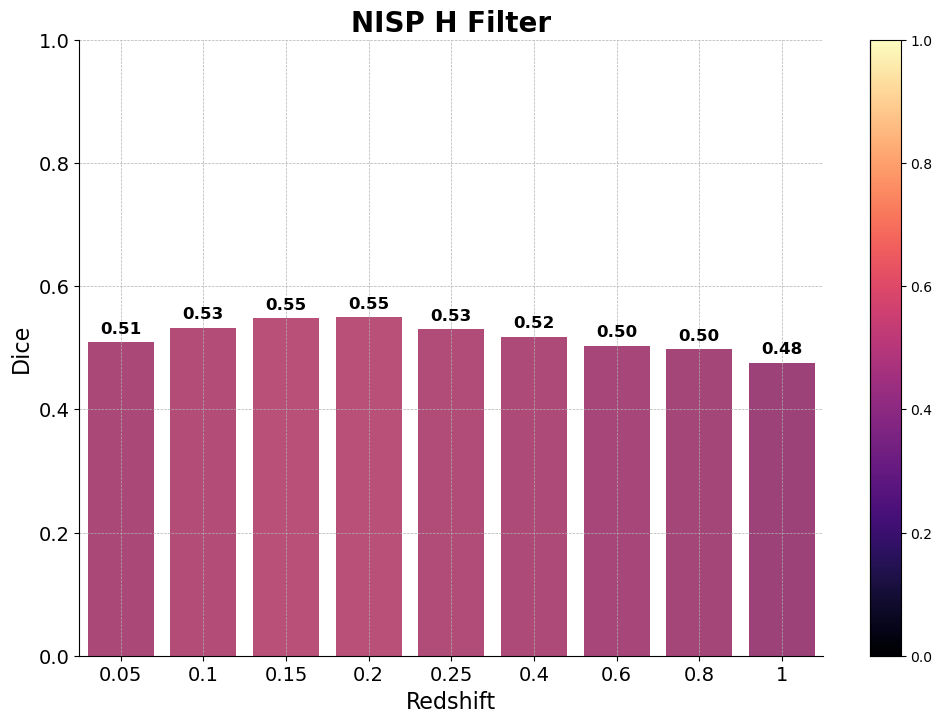

In [27]:
# Crear una paleta de colores en función de los valores alcanzados, normalizada entre 0 y 1
norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap="magma", norm=norm)
sm.set_array([])

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))

# Crear el gráfico de barras
bar_colors = [sm.to_rgba(valor) for valor in dices_medios_por_magnitud]
ax = sns.barplot(x=list(resultados_dice.keys()), y=dices_medios_por_magnitud, palette=bar_colors)

# Ajustar los límites del eje y entre 0 y 1
ax.set_ylim(0, 1)

# Añadir etiquetas con los valores sobre las barras
for i, valor in enumerate(dices_medios_por_magnitud):
    ax.text(i, valor + 0.01, f'{valor:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Añadir un título y ajustar etiquetas
plt.title('NISP H Filter', fontsize=20, fontweight='bold')
plt.xlabel('Redshift', fontsize=16)
plt.ylabel('Dice', fontsize=16)

# Ajustar el tamaño de las etiquetas de los ejes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Añadir líneas de cuadrícula
ax.grid(True, linestyle='--', linewidth=0.5)

# Añadir la barra de color (colorbar)
cbar = plt.colorbar(sm, ax=ax)

# Mejorar el diseño general
sns.despine()
#plt.savefig('images_paper/vis_filter_dice.png', dpi=300, bbox_inches='tight')
# Mostrar el gráfico
plt.show()

/tmp/ipykernel_1960717/3070687478.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados_dice.keys()), y=ious_medios_por_magnitud, palette=bar_colors)


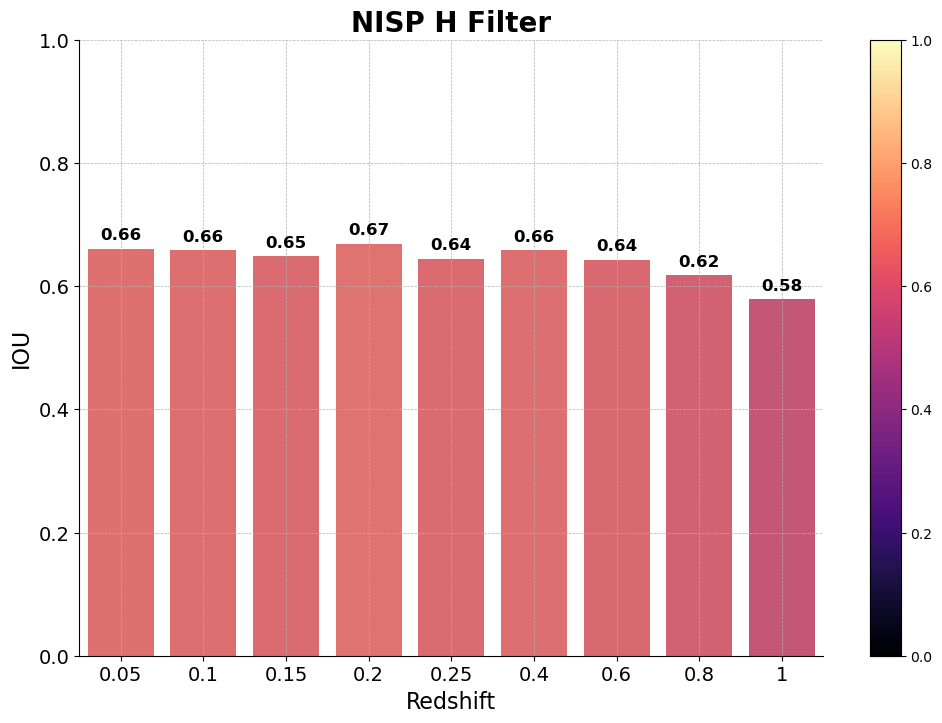

In [28]:
# Crear una paleta de colores en función de los valores alcanzados, normalizada entre 0 y 1
norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap="magma", norm=norm)
sm.set_array([])

# Ajustar el tamaño de la figura
plt.figure(figsize=(12, 8))

# Crear el gráfico de barras
bar_colors = [sm.to_rgba(valor) for valor in ious_medios_por_magnitud]
ax = sns.barplot(x=list(resultados_dice.keys()), y=ious_medios_por_magnitud, palette=bar_colors)

# Ajustar los límites del eje y entre 0 y 1
ax.set_ylim(0, 1)

# Añadir etiquetas con los valores sobre las barras
for i, valor in enumerate(ious_medios_por_magnitud):
    ax.text(i, valor + 0.01, f'{valor:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Añadir un título y ajustar etiquetas
plt.title('NISP H Filter', fontsize=20, fontweight='bold')
plt.xlabel('Redshift', fontsize=16)
plt.ylabel('IOU', fontsize=16)

# Ajustar el tamaño de las etiquetas de los ejes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Añadir líneas de cuadrícula
ax.grid(True, linestyle='--', linewidth=0.5)

# Añadir la barra de color (colorbar)
cbar = plt.colorbar(sm, ax=ax)

# Mejorar el diseño general
sns.despine()
#plt.savefig('images_paper/vis_filter_dice.png', dpi=300, bbox_inches='tight')
# Mostrar el gráfico
plt.show()

            1%        2%        3%        4%        5%
0.05  0.153428  0.438138  0.520793  0.696328  0.632084
0.1   0.267460  0.432089  0.614348  0.661460  0.624810
0.15  0.309756  0.437361  0.634887  0.653265  0.650479
0.2   0.303542  0.448468  0.613720  0.687582  0.636020
0.25  0.326394  0.446932  0.550739  0.659927  0.621439
0.4   0.369367  0.485522  0.535877  0.597782  0.560101
0.6   0.372166  0.503882  0.548038  0.560065  0.498682
0.8   0.376227  0.479971  0.525294  0.566699  0.512319
1     0.370672  0.451703  0.503495  0.536144  0.492913


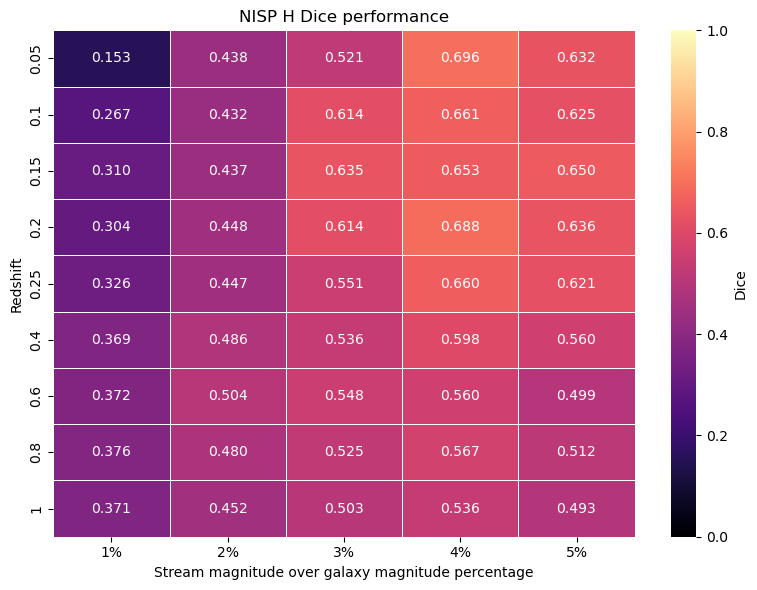

In [29]:
matrix_data_dice = {redshift: {key: np.nanmean(values) for key, values in subdict.items()} 
               for redshift, subdict in dice_results_redshift_with_mag_stream_percentage.items()}

labels_redshift = ['0.05','0.1','0.15','0.2','0.25','0.4','0.6','0.8','1']
labels_mag_percentage = ['1%','2%','3%','4%','5%']

# Convertir los datos en un DataFrame de Pandas
matrix_for_df = []
for redshift in labels_redshift:
    row = []
    for i, mag_label in enumerate(labels_mag_percentage, 1):  # 1, 2, 3, 4, 5
        if redshift in matrix_data_dice and i in matrix_data_dice[redshift]:
            row.append(matrix_data_dice[redshift][i])
        else:
            row.append(np.nan)
    matrix_for_df.append(row)

# Crear DataFrame
df = pd.DataFrame(matrix_for_df, index=labels_redshift, columns=labels_mag_percentage)

print(df)
# Crear el heatmap con anotaciones
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, fmt=".3f", cmap="magma", linewidths=0.5,
           cbar_kws={'label': 'Dice'}, vmin=0, vmax=1.0)

plt.xlabel('Stream magnitude over galaxy magnitude percentage')
plt.ylabel('Redshift')
plt.title("NISP H Dice performance")
plt.tight_layout()
plt.show()


            1%        2%        3%        4%        5%
0.05  0.273113  0.556805  0.731632  0.833868  0.799677
0.1   0.314137  0.528724  0.744682  0.789984  0.829555
0.15  0.320618  0.511644  0.726993  0.779105  0.824997
0.2   0.334770  0.558863  0.745488  0.827928  0.796645
0.25  0.349649  0.548370  0.671197  0.831097  0.754580
0.4   0.332678  0.573932  0.726017  0.822063  0.755196
0.6   0.334334  0.587987  0.668579  0.763512  0.775854
0.8   0.342322  0.543128  0.685980  0.735591  0.719632
1     0.341419  0.482718  0.629992  0.686367  0.701118


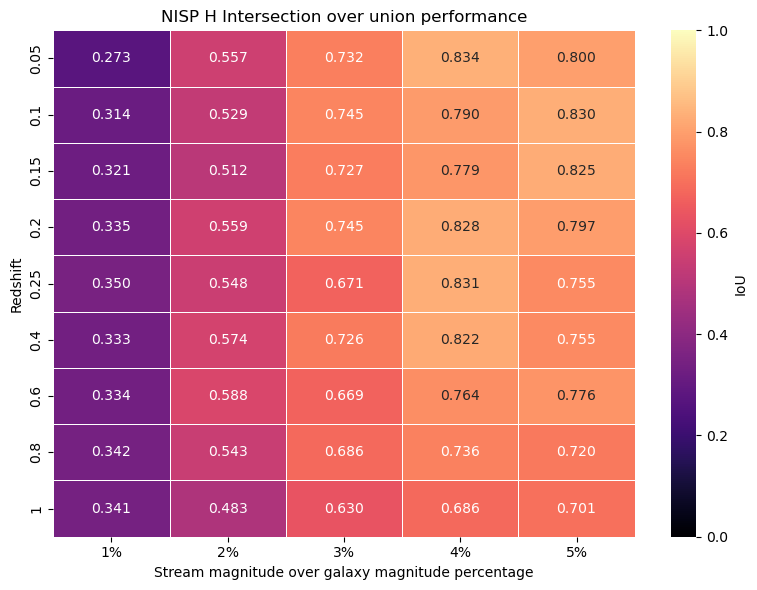

In [30]:
matrix_data_iou = {redshift: {key: np.nanmean(values) for key, values in subdict.items()} 
               for redshift, subdict in iou_results_redshift_with_mag_stream_percentage.items()}

labels_redshift = ['0.05','0.1','0.15','0.2','0.25','0.4','0.6','0.8','1']
labels_mag_percentage = ['1%','2%','3%','4%','5%']

# Convertir los datos en un DataFrame de Pandas
matrix_for_df = []
for redshift in labels_redshift:
    row = []
    for i, mag_label in enumerate(labels_mag_percentage, 1):  # 1, 2, 3, 4, 5
        if redshift in matrix_data_iou and i in matrix_data_iou[redshift]:
            row.append(matrix_data_iou[redshift][i])
        else:
            row.append(np.nan)
    matrix_for_df.append(row)

# Crear DataFrame
df = pd.DataFrame(matrix_for_df, index=labels_redshift, columns=labels_mag_percentage)

print(df)
# Crear el heatmap con anotaciones
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, fmt=".3f", cmap="magma", linewidths=0.5,
           cbar_kws={'label': 'IoU'}, vmin=0, vmax=1.0)

plt.xlabel('Stream magnitude over galaxy magnitude percentage')
plt.ylabel('Redshift')
plt.title("NISP H Intersection over union performance")
plt.tight_layout()
plt.show()


=== Dice vs Distance to Galaxy Center ===
          2-10     10-17     17-25     25-32     32-40
0.05  0.393055  0.500104  0.570533  0.550889  0.527602
0.1   0.451393  0.600986  0.531031  0.571044  0.541286
0.15  0.434017  0.585349  0.595142  0.632317  0.519978
0.2   0.451932  0.568401  0.574407  0.633321  0.547141
0.25  0.464924  0.559386  0.481725  0.646298  0.563135
0.4   0.442218  0.562710  0.494735  0.646044  0.511556
0.6   0.472498  0.505786  0.492546  0.581193  0.495862
0.8   0.498490  0.500170  0.510830  0.556024  0.441896
1     0.483452  0.459750  0.492999  0.538668  0.416737


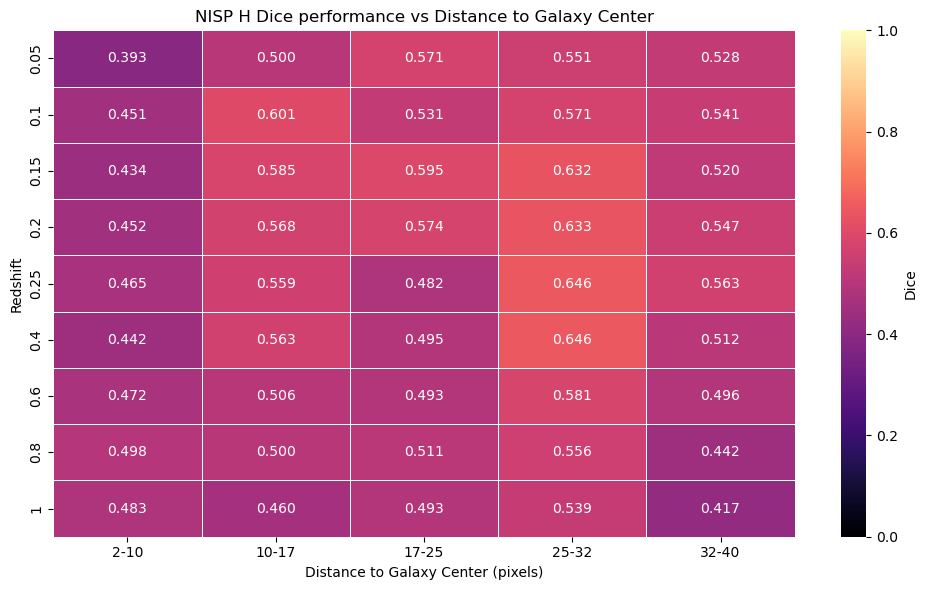

In [31]:
matrix_data_dice_distance = {
    redshift: {key: np.nanmean(values) for key, values in subdict.items()} 
    for redshift, subdict in dice_results_redshift_with_distance.items()
}

matrix_for_df_distance = []
for redshift in labels_redshift:
    row = []
    for distance_label in distance_labels:
        if redshift in matrix_data_dice_distance and distance_label in matrix_data_dice_distance[redshift]:
            row.append(matrix_data_dice_distance[redshift][distance_label])
        else:
            row.append(np.nan)
    matrix_for_df_distance.append(row)

df_distance = pd.DataFrame(matrix_for_df_distance, 
                          index=labels_redshift, 
                          columns=distance_labels)

print("\n=== Dice vs Distance to Galaxy Center ===")
print(df_distance)

plt.figure(figsize=(10, 6))
sns.heatmap(df_distance, annot=True, fmt=".3f", cmap="magma", 
           linewidths=0.5, cbar_kws={'label': 'Dice'}, 
           vmin=0, vmax=1.0)
plt.xlabel('Distance to Galaxy Center (pixels)')
plt.ylabel('Redshift')
plt.title("NISP H Dice performance vs Distance to Galaxy Center")
plt.tight_layout()
plt.show()


=== IoU vs Distance to Galaxy Center ===
          2-10     10-17     17-25     25-32     32-40
0.05  0.608182  0.724131  0.692889  0.675147  0.617131
0.1   0.588843  0.687222  0.688169  0.722047  0.626715
0.15  0.549591  0.647561  0.709631  0.759232  0.598447
0.2   0.583630  0.693479  0.701056  0.774487  0.628510
0.25  0.609602  0.650405  0.606760  0.756194  0.654010
0.4   0.577407  0.719103  0.654039  0.763871  0.638326
0.6   0.577023  0.702922  0.631183  0.724169  0.626940
0.8   0.664479  0.622903  0.621105  0.673544  0.531946
1     0.608938  0.561531  0.545856  0.662705  0.551009


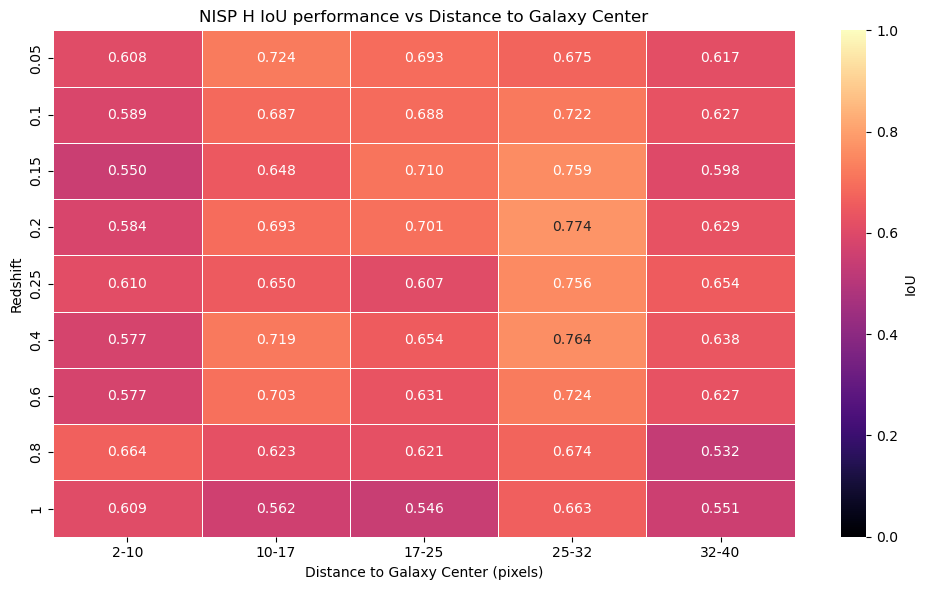

In [32]:
matrix_data_iou_distance = {
    redshift: {key: np.nanmean(values) for key, values in subdict.items()} 
    for redshift, subdict in iou_results_redshift_with_distance.items()
}

matrix_for_df_iou_distance = []
for redshift in labels_redshift:
    row = []
    for distance_label in distance_labels:
        if redshift in matrix_data_iou_distance and distance_label in matrix_data_iou_distance[redshift]:
            row.append(matrix_data_iou_distance[redshift][distance_label])
        else:
            row.append(np.nan)
    matrix_for_df_iou_distance.append(row)

df_iou_distance = pd.DataFrame(matrix_for_df_iou_distance, 
                              index=labels_redshift, 
                              columns=distance_labels)

print("\n=== IoU vs Distance to Galaxy Center ===")
print(df_iou_distance)

plt.figure(figsize=(10, 6))
sns.heatmap(df_iou_distance, annot=True, fmt=".3f", cmap="magma", 
           linewidths=0.5, cbar_kws={'label': 'IoU'}, 
           vmin=0, vmax=1.0)
plt.xlabel('Distance to Galaxy Center (pixels)')
plt.ylabel('Redshift')
plt.title("NISP H IoU performance vs Distance to Galaxy Center")
plt.tight_layout()
plt.show()